# Exercise 4a 

Deadline 18.12.2025

Anna Bütfering

Lea Neumann

Juan Provencio

## 1. Simulation setup

The physics way to simulate epidemiology depends on the following differential equations:

$$ \dot{S} = - \lambda \dfrac{S \cdot I}{N} $$

$$ \dot{I} = \lambda \dfrac{S \cdot I}{N} - \mu \cdot I $$

$$ \dot{R} = \mu \cdot I $$

with the constraint

$$ N = S + I + R $$

of the total population.

These equations are discretized $\mathrm{d} t\to \Delta t$ for sequences of days $\Delta t = 1 \mathrm{\,day}$  where the progress of the epidemic is tracked. Therefore, e.g. $\Delta S(t) = S(t - 1) - S(t)$. We also normalize the equations so that they're independent of population size $N$. We simulate the evolution by solving for the current values:

$$ S(t+\Delta t)=S(t)−\lambda S(t)I(t) \Delta t $$

$$I(t + \Delta t) = I(t) + (\lambda S(t) I(t) - \mu I(t)) \Delta t $$

$$ R(t + \Delta t) = R(t) + \mu I(t) \Delta t $$

etc.

In [1]:
# Torch
import numpy as np 
print("Numpy version:", np.__version__)
import torch 
from torch.nn import functional as F
from torch import nn, optim
from torch import sqrt, exp
# Sklearn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
# Etc.
import matplotlib.pyplot as plt
from tqdm import tqdm
## Plot options
from cycler import cycler
from matplotlib import rcParams
rcParams['axes.grid'] = True
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.5
rcParams['axes.labelsize'] = 20
rcParams['axes.prop_cycle'] = cycler('color', ['#C61A27', '#3891A6', \
                                               '#F79D65', '#FDE74C', \
                                                '#9BC53D', '#5BC0EB',
                                                '#E55934', '#FA7921',
                                                '#8D230F', '#1B998B'])
colors = rcParams['axes.prop_cycle'].by_key()['color']
rcParams['axes.titlesize'] = 22
rcParams['figure.figsize'] = (12, 7)
rcParams['figure.titlesize'] = 26
rcParams['font.size'] = 16
rcParams['image.cmap'] = 'magma'
rcParams['lines.markeredgewidth'] = 2
rcParams['lines.markerfacecolor'] = 'white'
rcParams['markers.fillstyle'] = 'none'
# Define textbox style for plots
textbox_style = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')

Numpy version: 1.26.4


First, we implement a simulation of the SIR model. It's important to choose appropriate starting conditions.

Text(0.5, 0, 'Time')

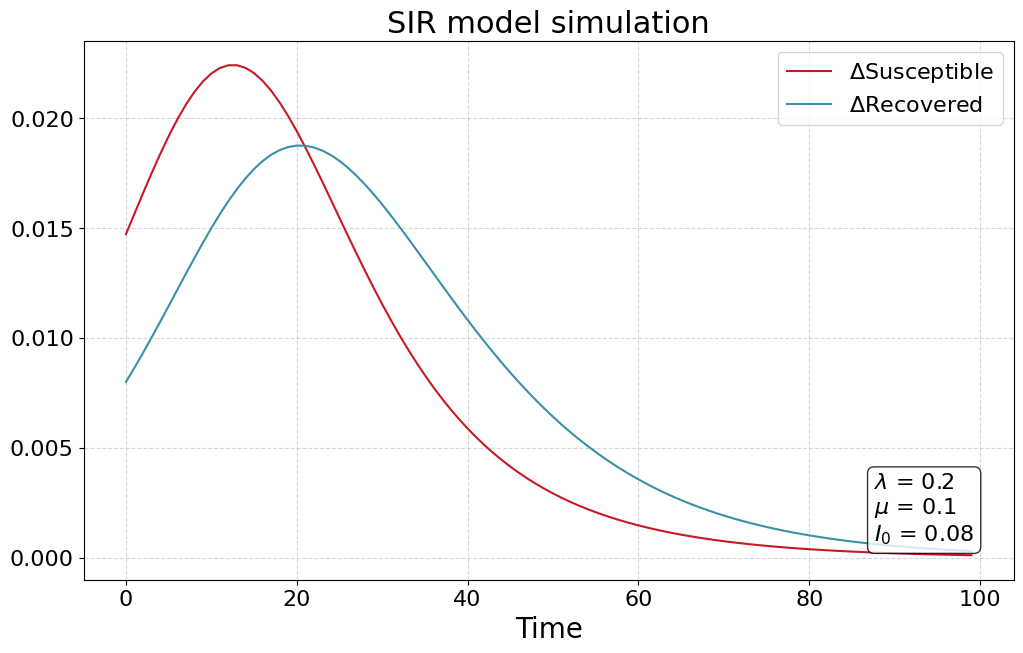

In [2]:
# Simple SIR simulation
def simulate_sir_simple(lam, mu, I_0, T, Delta_t = 1.0):
    # Initialize starting conditions
    S_0 = 1.0 - I_0
    R_0 = 0.0
    # Time evolution
    S = S_0
    I = I_0
    R = R_0
    x = []
    c = []
    for t in range(T):
        # Update equations
        x.append((+lam * S * I * Delta_t, # Positive by convention
                  mu * I * Delta_t))
        c.append((S, I, R))
        # Next step
        S = S - lam * S * I * Delta_t
        I = I + lam * S * I * Delta_t - mu * I * Delta_t
        R = R + mu * I * Delta_t

        #print(S + I + R)  # This should always be 1, 
        # but it's not exactly due to numerical error from the discretization

    return x, c

params = [0.2, 0.1, 0.08]
x, c = simulate_sir_simple(lam = params[0], mu = params[1], I_0 = params[2], 
                        T = 100, Delta_t = 1.0)
fig = plt.figure()
plt.plot(np.array(x)[:,0], label='$\Delta$Susceptible')
#plt.plot(np.array(x)[:,1], label='$\Delta$Infected')
plt.plot(np.array(x)[:,1], label='$\Delta$Recovered')
plt.title('SIR model simulation')
# Parameter box
param_text = f"$\\lambda$ = {params[0]}\n$\\mu$ = {params[1]}\n$I_0$ = {params[2]}"
plt.gca().text(0.85, 0.2, param_text, transform=plt.gca().transAxes, fontsize=16,
        verticalalignment='top', bbox=textbox_style)
plt.legend()
plt.xlabel('Time')

        

We run different simulations for different starting parameters and find such that the epidemics are interesting, e.g. don't already end by day 30, i.e. the change in infections should not stabilize too soon, and don't unfold only after day 70, i.e. the change in infections spikes too late.

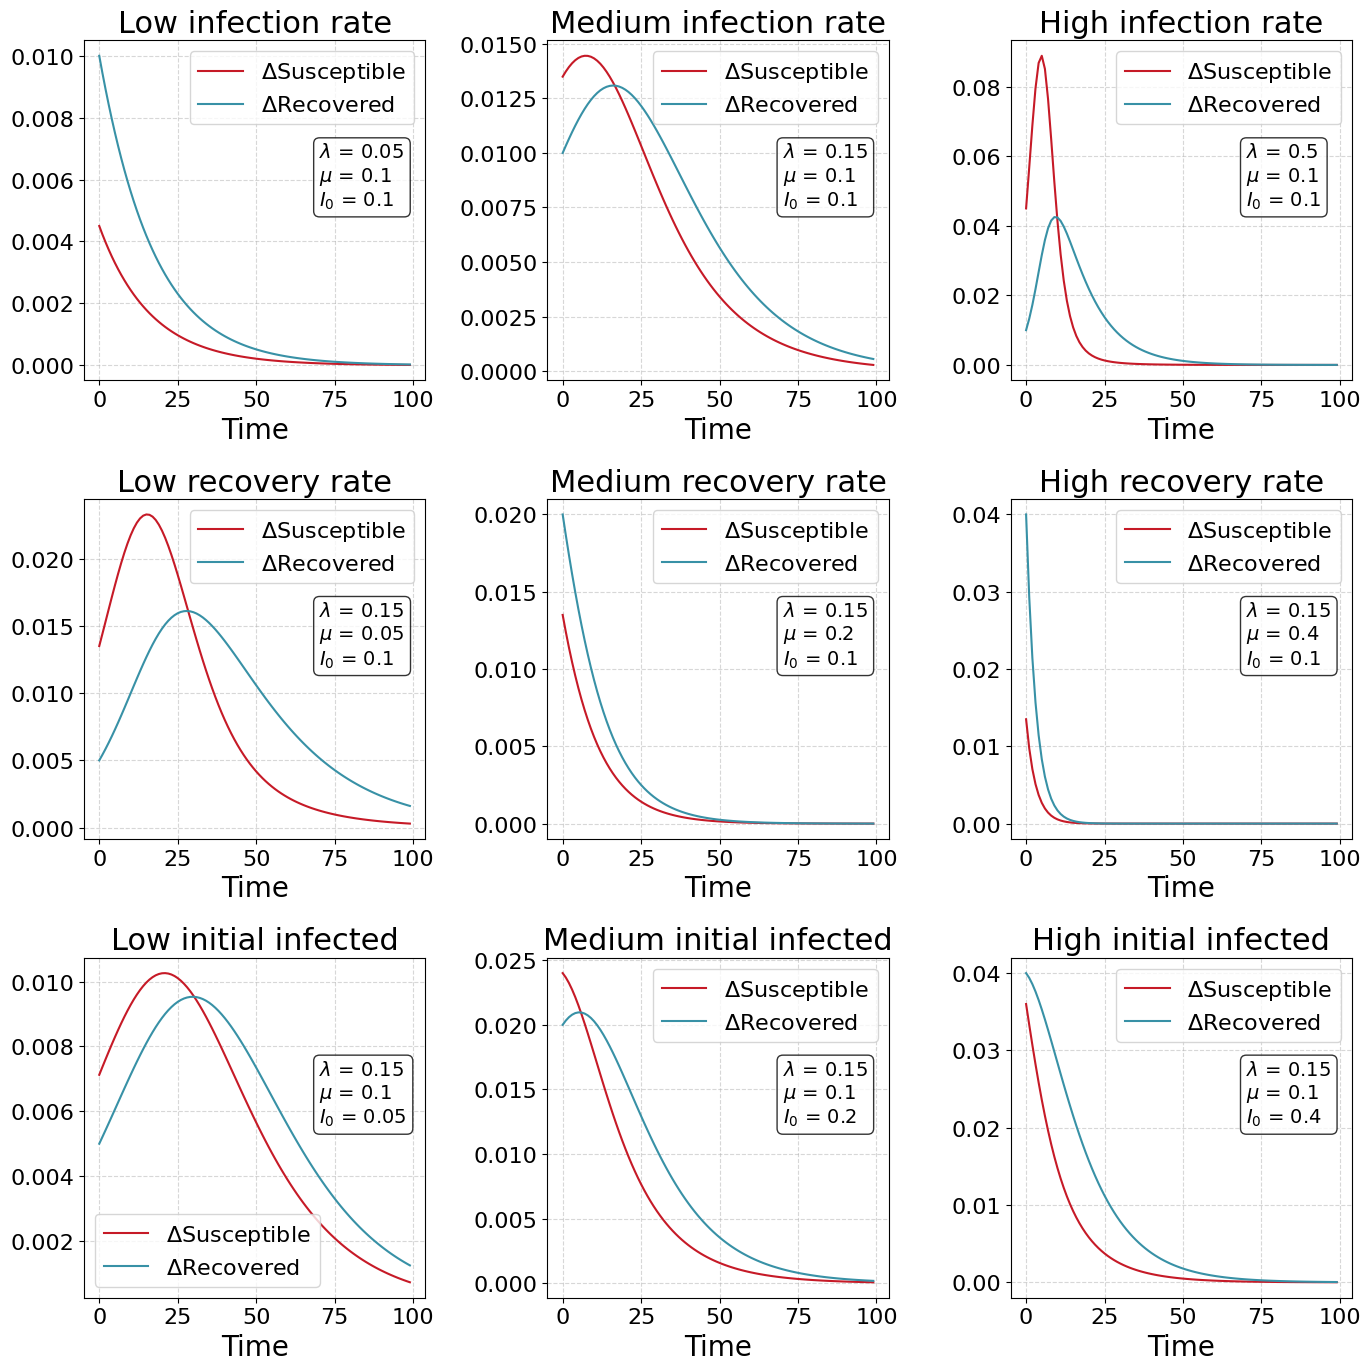

In [3]:
params = [(0.05, 0.1, 0.1), (0.15, 0.1, 0.1), (0.5, 0.1, 0.1), 
          (0.15, 0.05, 0.1), (0.15, 0.2, 0.1), (0.15, 0.4, 0.1), 
          (0.15, 0.1, 0.05), (0.15, 0.1, 0.2), (0.15, 0.1, 0.4)]
titles = ['Low infection rate', 'Medium infection rate', 'High infection rate',
          'Low recovery rate', 'Medium recovery rate', 'High recovery rate',
          'Low initial infected', 'Medium initial infected', 'High initial infected']

fig, axes = plt.subplots(3, 3, figsize=(14,14))
for i, ax in enumerate(axes.flatten()):
    x, c = simulate_sir_simple(lam = params[i][0], mu = params[i][1], I_0 = params[i][2], 
                            T = 100, Delta_t = 1.0)
    ax.plot(np.array(x)[:,0], label='$\Delta$Susceptible')
    #ax.plot(np.array(x)[:,1], label='$\Delta$Infected')
    ax.plot(np.array(x)[:,1], label='$\Delta$Recovered')
    ax.set_title(titles[i])
    # Parameter box
    param_text = f"$\\lambda$ = {params[i][0]}\n$\\mu$ = {params[i][1]}\n$I_0$ = {params[i][2]}"
    ax.text(0.69, 0.7, param_text, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', bbox=textbox_style)
    ax.legend()
    ax.set_xlabel('Time')
fig.tight_layout()

From these experiments we define the simulation prior

$$ p^{\mathrm{sim}}(Y) = p^{\mathrm{sim}}(\lambda) \cdot p^{\mathrm{sim}}(\mu) \cdot p^{\mathrm{sim}}(I_0) $$

Our observations lead to excluding very high recovery rates, in particular with respect to the infection rates. In those cases, the disease is erradicated very quickly. Similarly for very high infection rates in comparison to the recovery rates. In the most interesting distributions, there isn't a large difference between the infection rate $\lambda$ and recovery rate $\mu$. A slightly higher infection rate than recovery rate provides the most diverse curves. We decide to sample:

$$ p^{\mathrm{sim}}(\lambda) = \mathrm{uniform}(0.1, 0.4) $$

$$ p^{\mathrm{sim}}(\mu) = \mathrm{uniform}(0.05, 0.25) $$

$$ p^{\mathrm{sim}}(I_0) = \mathrm{uniform}(0.05, 0.4) $$

Although there is obviously a lot of arbitrarity to this choice.

## 2. Point estimation

We train an ordinary feed forward network $\Phi$ with the square loss using a training set generated by the simulation and prior distribution from Task 1.

In [71]:
class PointEstimatorNN(nn.Module):
    def __init__(self, layers_sizes=[128, 64]):
        # Init 
        self.losses = []

        super().__init__()
        # Ordinary Feed Forward Network Architecture with ReLU activations
        # Keep in mind, input is of size 100
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(200, layers_sizes[0]))  # Input layer: 100 days * 2 features (delta S, delta R)
        # Hidden variables with variable sizes
        for i in range(len(layers_sizes) - 1):
            self.layers.append(nn.Linear(layers_sizes[i], layers_sizes[i+1]))
        self.output_layer = nn.Linear(layers_sizes[-1], 3)  # Output: lam, mu, I_0

    def forward(self, X):
        for layer in self.layers:
            X = F.relu(layer(X))
        X = self.output_layer(X)
        return X

    
    def train(self, X_train, y_train, n_epochs, lr=0.01):
        loss_fn = nn.MSELoss()
        optimizer = optim.Adam(self.parameters(), lr=lr)
        dataset = torch.utils.data.TensorDataset(X_train, y_train)
        loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

        for epoch in tqdm(range(n_epochs)):
            for x_batch, y_batch in loader:
                # Zero gradients
                optimizer.zero_grad()
                # Forward pass
                y_hat = self(x_batch)
                # Loss
                loss = loss_fn(y_hat, y_batch)
                # Backward pass and optimization
                loss.backward()
                optimizer.step()
            self.losses.append(loss.item())

        return self
    
# Generate training data
def generate_training_data(n_samples, T):
    X_train = []
    y_train = []
    for _ in range(n_samples):
        # Sample from prior
        lam = np.random.uniform(0.1, 0.4)
        mu = np.random.uniform(0.05, 0.25)
        I_0 = np.random.uniform(0.05, 0.4)
        # Simulate SIR
        x, c = simulate_sir_simple(lam, mu, I_0, T)
        X_train.append(np.array(x).flatten())
        y_train.append([lam, mu, I_0])
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)
    return X_train, y_train


X_train, y_train = generate_training_data(n_samples=1000, T=100)


# Train model 10 times with same architecture, save results
models = []
for _ in range(10):
    model = PointEstimatorNN(layers_sizes=[64, 32])
    model.train(X_train, y_train, n_epochs=200, lr=0.001)
    models.append(model)


100%|██████████| 200/200 [00:12<00:00, 16.56it/s]


Now we test the model on new samples generated by the simulation. We use this as a starting point and will later analyze different parameters, especially the size of the network and training set.

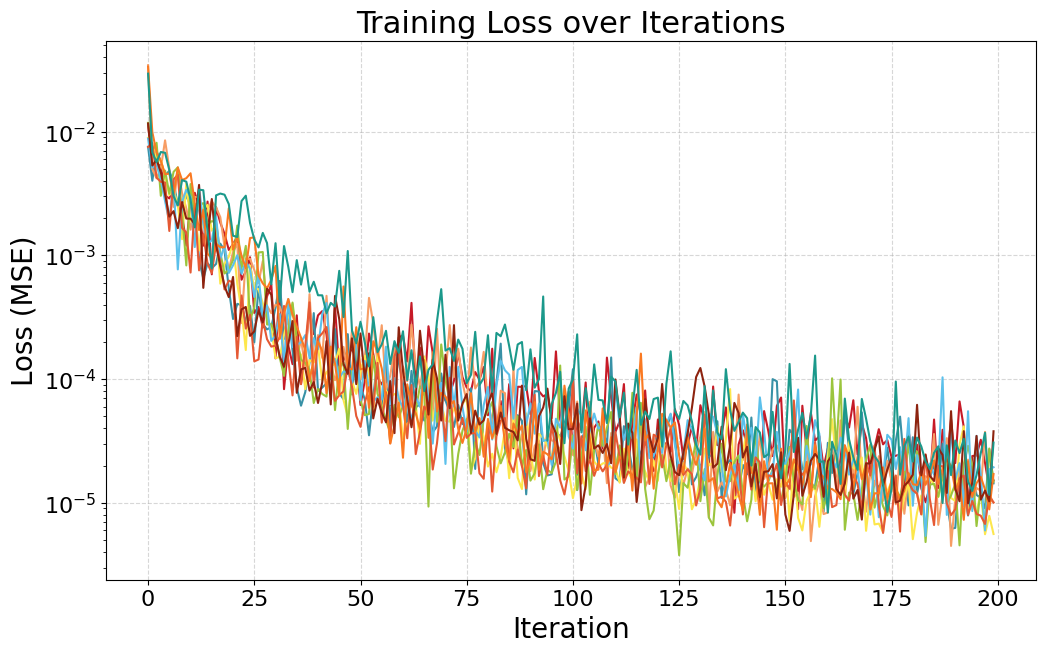

In [91]:
# Test on new samples
X_test, y_test = generate_training_data(n_samples=100, T=100)
y_preds = [model(X_test).detach().numpy() for model in models]
loss_values = [model.losses for model in models]

def plot_results(y_test, y_pred, loss_values, average = False, resids = True, hists = True, losses = True):
    # If y_pred is a list of predictions, average them
    if isinstance(y_pred, list) and average:
        y_pred = np.mean(np.array(y_pred), axis=0)
    elif isinstance(y_pred, list) and not average:
        # Plot results for each model
        if resids:
            fig, axes = plt.subplots(1, 3, figsize=(18,6))
            param_names = ['$\\lambda$', '$\\mu$', '$I_0$']
            for i in range(3):
                for y_pred_i in y_pred:
                    axes[i].scatter((y_test[:,i] - y_pred_i[:,i]) / y_test[:,i] * 100, y_pred_i[:,i], alpha=0.7)
                    axes[i].axvline(0, color='r', linestyle='--')  # Diagonal line
                    axes[i].set_xlabel(f'Relative residuals for {param_names[i]} [%]')
                    axes[i].set_ylabel(f'Predicted {param_names[i]}')
                    axes[i].set_title(f'Parameter Estimation for {param_names[i]}')
            plt.tight_layout()

        # Plot residuals
        if hists:
            fig, axes = plt.subplots(1, 3, figsize=(18,6))
            param_names = ['$\\lambda$', '$\\mu$', '$I_0$']
            means = []
            stds = []
            for i in range(3):
                for y_pred_i in y_pred:
                    residuals = (y_test[:,i] - y_pred_i[:,i]) / y_test[:,i] * 100
                    axes[i].hist(residuals, bins=20, alpha=0.3, color=colors[i])
                    axes[i].set_xlabel(f'Relative Residuals for {param_names[i]} [%]')
                    axes[i].set_ylabel('Frequency')
                    axes[i].set_title(f'Residuals Distribution for {param_names[i]}')
                    means.append(residuals.mean())
                    stds.append(residuals.std())

                mean = np.mean(means)
                std = np.mean(stds)

                axes[i].text(0.95, 0.95, f'Mean: {mean:.1f}\nStd: {std:.1f}', transform=axes[i].transAxes,
                            verticalalignment='top', horizontalalignment='right', bbox=textbox_style)
            plt.tight_layout()
            
        # Plot losses
        if losses:
            plt.figure()
            for loss_value in loss_values:
                plt.plot(loss_value)
            plt.yscale('log')
            plt.xlabel('Iteration')
            plt.ylabel('Loss (MSE)')
            plt.title('Training Loss over Iterations')
            plt.show()
        
    else:
        # Plot results
        if resids:
            fig, axes = plt.subplots(1, 3, figsize=(18,6))
            param_names = ['$\\lambda$', '$\\mu$', '$I_0$']
            for i in range(3):
                axes[i].scatter((y_test[:,i] - y_pred[:,i]) / y_test[:,i] * 100, y_pred[:,i], alpha=0.7)
                axes[i].axvline(0, color='r', linestyle='--')  # Diagonal line
                axes[i].set_xlabel(f'Relative residuals for {param_names[i]} [%]')
                axes[i].set_ylabel(f'Predicted {param_names[i]}')
                axes[i].set_title(f'Parameter Estimation for {param_names[i]}')
            plt.tight_layout()

        # Plot residuals
        if hists:
            fig, axes = plt.subplots(1, 3, figsize=(18,6))
            param_names = ['$\\lambda$', '$\\mu$', '$I_0$']
            for i in range(3):
                residuals = (y_test[:,i] - y_pred[:,i]) / y_test[:,i] * 100
                mean = residuals.mean()
                std = residuals.std()
                axes[i].hist(residuals, bins=20, alpha=0.7, color=colors[i])
                axes[i].set_xlabel(f'Relative Residuals for {param_names[i]} [%]')
                axes[i].set_ylabel('Frequency')
                axes[i].set_title(f'Residuals Distribution for {param_names[i]}')
                axes[i].text(0.95, 0.95, f'Mean: {mean:.1f}\nStd: {std:.1f}', transform=axes[i].transAxes,
                            verticalalignment='top', horizontalalignment='right', bbox=textbox_style)
            plt.tight_layout()

        # Plot losses
        if losses:
            plt.figure()
            plt.plot(model.losses)
            plt.yscale('log')
            plt.xlabel('Iteration')
            plt.ylabel('Loss (MSE)')
            plt.title('Training Loss over Iterations')
            plt.show()

plot_results(y_test.numpy(), y_preds[:10], loss_values[:10], resids = False, hists = False, losses = True)

Visually, the predictions lie very neatly on top of the real values. This is corroborated first by the relative residuals, where we see that the deviations from the expected values lie within less than 5% from the true values.

We don't recognize systematic deviations when experiment on multiple samples

We move on and test a smaller network size:

In [58]:
network_sizes = [[64, 32], [32, 32], [16, 16]]

models = []
for i, layers in enumerate(network_sizes):
    model = PointEstimatorNN(layers_sizes=layers)
    model.train(X_train, y_train, n_epochs=200, lr=0.001)
    models.append(model)

100%|██████████| 200/200 [00:08<00:00, 23.23it/s]


A smaller network seems to be less biased but have a larger error margin. The standard deviations are about twice as large as the first network. Let's try even smaller: